# 3D Gaussian Splatting, built step by step

Each section: **math recap → try it yourself (stub function) → self-check → solution**.
Try the stub before looking at the solution cell — the self-check cells will tell you
immediately if you're right, using hand-computable numbers, not just "did it run."

Run the setup cell first.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print("device:", device)


device: cuda


## Step 1 — A single 3D Gaussian's covariance

**Math:** we never store $\Sigma$ directly (raw 3x3 matrices break positive-definiteness
under gradient steps). Instead:

$$\Sigma = R\,S\,S^T R^T$$

where $S = \text{diag}(s_x,s_y,s_z)$ (positive scales) and $R$ is a rotation matrix built
from a quaternion $(w,x,y,z)$. This is the "always-valid-by-construction" trick.

**Rotation from quaternion** (standard formula, just implement it directly):

$$R = \begin{bmatrix}
1-2(y^2+z^2) & 2(xy-wz) & 2(xz+wy) \\
2(xy+wz) & 1-2(x^2+z^2) & 2(yz-wx) \\
2(xz-wy) & 2(yz+wx) & 1-2(x^2+y^2)
\end{bmatrix}$$

**Your task:** implement `quat_to_R` and `build_covariance`.

**Sanity check to reason through before running:** if the quaternion is the identity
rotation $(1,0,0,0)$, then $R = I$, so $\Sigma$ should reduce to just $\text{diag}(s_x^2,s_y^2,s_z^2)$
— a scale with no rotation should give you back exactly the axis-aligned ellipsoid you'd expect.
That's what the self-check below tests.


In [2]:
def quat_to_R(q):
    """q: (4,) tensor (w,x,y,z), assumed already normalized. Return (3,3) rotation matrix."""
    w, x, y, z = q.unbind(-1)
    R = torch.stack([
        1 - 2 * (y**2 + z**2), 2 * (x*y - w*z),       2 * (x*z + w*y),
        2 * (x*y + w*z),       1 - 2 * (x**2 + z**2), 2 * (y*z - w*x),
        2 * (x*z - w*y),       2 * (y*z + w*x),       1 - 2 * (x**2 + y**2),
    ]).reshape(3, 3)
    return R

def normalize_quaternion(quat):
    inv_length = 1.0 / (torch.norm(quat) + 1e-8)
    return quat * inv_length

def build_covariance(scale, quat):
    """scale: (3,) positive scales. quat: (4,) unnormalized quaternion.
    Return (3,3) covariance Sigma = R S S^T R^T."""
    # YOUR CODE HERE
    quat = normalize_quaternion(quat)
    R = quat_to_R(quat)
    S = torch.diag(scale)
    
    RS = torch.matmul(R, S) # (3, 1)
    StRt = torch.matmul(S, R.T) # (3, 3)

    
    return torch.matmul(RS, StRt)

print(build_covariance(torch.tensor([1., 2., 3.,], dtype=torch.float32), torch.tensor([1, 0, 0, 0], dtype=torch.float32)).numpy())


[[1. 0. 0.]
 [0. 4. 0.]
 [0. 0. 9.]]


In [3]:
# --- self-check: don't edit, just run ---
try:
    q_identity = torch.tensor([1., 0., 0., 0.])
    s = torch.tensor([0.1, 0.2, 0.3])
    Sigma = build_covariance(s, q_identity)
    expected = torch.diag(s ** 2)
    assert torch.allclose(Sigma, expected, atol=1e-5), f"got {Sigma}, expected diag {expected}"
    print("Step 1 PASSED:", Sigma.diagonal())
except NotImplementedError:
    print("Fill in quat_to_R and build_covariance above, then re-run this cell.")


Step 1 PASSED: tensor([0.0100, 0.0400, 0.0900])


**Solution** (try it yourself first — scroll past once you've attempted it):

In [4]:
def quat_to_R(q):
    q = F.normalize(q, dim=-1)
    w, x, y, z = q.unbind(-1)
    R = torch.stack([
        1 - 2 * (y**2 + z**2), 2 * (x*y - w*z),       2 * (x*z + w*y),
        2 * (x*y + w*z),       1 - 2 * (x**2 + z**2), 2 * (y*z - w*x),
        2 * (x*z - w*y),       2 * (y*z + w*x),       1 - 2 * (x**2 + y**2),
    ]).reshape(3, 3)
    return R

def build_covariance(scale, quat):
    R = quat_to_R(quat)
    S = torch.diag(scale)
    RS = R @ S
    return RS @ RS.T

# re-run the self-check
q_identity = torch.tensor([1., 0., 0., 0.])
s = torch.tensor([0.1, 0.2, 0.3])
Sigma = build_covariance(s, q_identity)
print(Sigma)


tensor([[0.0100, 0.0000, 0.0000],
        [0.0000, 0.0400, 0.0000],
        [0.0000, 0.0000, 0.0900]])


## Step 2 — World to camera (the *exact*, non-approximated transform)

**Math:** $x_{cam} = R_{cw}\,x_{world} + t_{cw}$ — an ordinary rigid transform, same
extrinsics convention you already use for pinhole cameras. Because this map is linear,
covariance transforms exactly: $\Sigma_{cam} = R_{cw}\,\Sigma\,R_{cw}^T$ — no Jacobian
needed here, that's only required in the next step where the map becomes nonlinear.

**Your task:** implement both the point transform and the covariance transform.

**Problem to think through first:** if $R_{cw}=I$ (camera axis-aligned with world) and
$t_{cw} = (0,0,5)$, and a Gaussian sits at the world origin with $\Sigma = \sigma^2 I$ —
what should $x_{cam}$ and $\Sigma_{cam}$ be? (Answer: $x_{cam}=(0,0,5)$, and $\Sigma_{cam}$
is unchanged, still $\sigma^2 I$, since a pure translation doesn't rotate or stretch the
blob at all.) The self-check below verifies exactly this case.


In [5]:
def world_to_cam_point(x_world, R_cw, t_cw):
    """x_world: (3,). Return (3,) camera-space point."""
    return torch.matmul(R_cw, x_world) + t_cw

def world_to_cam_covariance(Sigma, R_cw):
    """Sigma: (3,3) world-space covariance. Return (3,3) camera-space covariance."""
    return R_cw @ Sigma @ R_cw.T

In [6]:
# --- self-check ---
try:
    R_cw = torch.eye(3)
    t_cw = torch.tensor([0., 0., 5.])
    x_world = torch.zeros(3)
    x_cam = world_to_cam_point(x_world, R_cw, t_cw)
    assert torch.allclose(x_cam, torch.tensor([0., 0., 5.])), x_cam

    Sigma = (0.2 ** 2) * torch.eye(3)
    Sigma_cam = world_to_cam_covariance(Sigma, R_cw)
    assert torch.allclose(Sigma_cam, Sigma), Sigma_cam
    print("Step 2 PASSED:", x_cam, Sigma_cam.diagonal())
except NotImplementedError:
    print("Fill in the two functions above, then re-run.")


Step 2 PASSED: tensor([0., 0., 5.]) tensor([0.0400, 0.0400, 0.0400])


**Solution:**

In [7]:
def world_to_cam_point(x_world, R_cw, t_cw):
    return R_cw @ x_world + t_cw

def world_to_cam_covariance(Sigma, R_cw):
    return R_cw @ Sigma @ R_cw.T

R_cw = torch.eye(3); t_cw = torch.tensor([0., 0., 5.])
print(world_to_cam_point(torch.zeros(3), R_cw, t_cw))


tensor([0., 0., 5.])


## Step 3 — Perspective projection of the mean (ordinary pinhole, no covariance yet)

**Math:** $\pi(x,y,z) = (f_x x/z,\ f_y y/z)$, then add the principal point offset
$(c_x, c_y)$ to get actual pixel coordinates.

**Your task:** implement `project_point`.

**Problem to think through:** with $f_x=f_y=100$, $c_x=c_y=32$, a point at camera-space
$(0,0,5)$ (straight ahead) should land exactly at the image center $(32,32)$ — verify
that by hand before running: $100\cdot 0/5 + 32 = 32$. A point at $(1,0,5)$ should land at
$100\cdot 1/5 + 32 = 20+32 = 52$.


In [8]:
def project_point(x_cam, fx, fy, cx, cy):
    """x_cam: (3,) camera-space point. Return (2,) pixel coordinates."""

    x = fx * x_cam[0] / x_cam[2] + cx
    y = fy * x_cam[1] / x_cam[2] + cy
    
    return torch.stack([x, y])


In [9]:
# --- self-check ---
try:
    p1 = project_point(torch.tensor([0., 0., 5.]), 100., 100., 32., 32.)
    assert torch.allclose(p1, torch.tensor([32., 32.])), p1
    p2 = project_point(torch.tensor([1., 0., 5.]), 100., 100., 32., 32.)
    assert torch.allclose(p2, torch.tensor([52., 32.])), p2
    print("Step 3 PASSED:", p1, p2)
except NotImplementedError:
    print("Fill in project_point above, then re-run.")


Step 3 PASSED: tensor([32., 32.]) tensor([52., 32.])


**Solution:**

In [10]:
def project_point(x_cam, fx, fy, cx, cy):
    x, y, z = x_cam[0], x_cam[1], x_cam[2]
    return torch.stack([fx * x / z + cx, fy * y / z + cy])

print(project_point(torch.tensor([1., 0., 5.]), 100., 100., 32., 32.))


tensor([52., 32.])


## Step 4 — The Jacobian: why we need it, and building it

**Why:** $\pi$ has a $1/z$ in it — nonlinear — so covariance doesn't transform through it
exactly the way it did in Step 2. We locally approximate $\pi$ by its tangent-plane
(first-order Taylor) approximation at the Gaussian's mean:

$$\pi(x) \approx \pi(\mu) + J(x-\mu), \qquad
J = \begin{bmatrix} f_x/z & 0 & -f_x x/z^2 \\ 0 & f_y/z & -f_y y/z^2 \end{bmatrix}$$

$J$ answers: "if I nudge the 3D point a tiny bit, how much does the 2D pixel move?"

**Your task:** implement `perspective_jacobian`.

**Problem to think through:** we can *check* a Jacobian numerically without trusting the
formula, using the definition of a derivative: nudge $x$ by a tiny $\epsilon$ and see how
much $\pi$ actually moved, then compare to $J \cdot [\epsilon,0,0]$. That's exactly
what the self-check does — this finite-difference check is a good habit to keep any time
you hand-derive a Jacobian, not just here.


In [11]:
def perspective_jacobian(x_cam, fx, fy):
    """x_cam: (3,) camera-space point. Return (2,3) Jacobian of pi() at x_cam."""
    x, y, z = x_cam[0], x_cam[1], x_cam[2]
    return torch.tensor([
        [fx/z, 0., -fx*x/z**2],
        [0., fy/z, -fy*y/z**2]
    ])


In [12]:
# --- self-check: compare analytic J against finite differences ---
try:
    x_cam = torch.tensor([1., 0.5, 5.])
    fx = fy = 100.
    J = perspective_jacobian(x_cam, fx, fy)

    eps = 1e-4
    numeric_cols = []
    for i in range(3):
        dx = torch.zeros(3); dx[i] = eps
        diff = (project_point(x_cam + dx, fx, fy, 0., 0.)
                - project_point(x_cam - dx, fx, fy, 0., 0.)) / (2 * eps)
        numeric_cols.append(diff)
    J_numeric = torch.stack(numeric_cols, dim=1)

    assert torch.allclose(J, J_numeric, atol=1e-2), f"analytic:\n{J}\nnumeric:\n{J_numeric}"
    print("Step 4 PASSED, J =\n", J)
except NotImplementedError:
    print("Fill in perspective_jacobian above, then re-run.")


Step 4 PASSED, J =
 tensor([[20.,  0., -4.],
        [ 0., 20., -2.]])


**Solution:**

In [13]:
def perspective_jacobian(x_cam, fx, fy):
    x, y, z = x_cam[0], x_cam[1], x_cam[2]
    return torch.tensor([
        [fx / z, 0.,     -fx * x / z**2],
        [0.,     fy / z, -fy * y / z**2],
    ])

print(perspective_jacobian(torch.tensor([1., 0.5, 5.]), 100., 100.))

tensor([[20.,  0., -4.],
        [ 0., 20., -2.]])


## Step 5 — EWA splatting: put Steps 1-4 together to get $\Sigma_{2D}$

**Math:** $\Sigma_{2D} = J\,\Sigma_{cam}\,J^T$ — apply the Step-0 covariance rule again,
now using the *local linear approximation* $J$ instead of an exact linear map.

**Your task:** implement `project_covariance_to_2d`.

**Problem to think through (the isotropic sanity check from our discussion):** if
$\Sigma_{cam} = \sigma^2 I$ and the point is dead-center, $x=y=0$, then $J$'s
$-f x/z^2$ terms vanish and $J$ reduces to just $\text{diag}(f/z, f/z)$ (padded with a
zero column). Work out $J\Sigma_{cam}J^T$ by hand: it should come out to exactly
$\sigma^2 (f/z)^2 I_2$ — i.e. the blob's on-screen radius is its real radius times the
ordinary "size shrinks by $f/z$ with distance" pinhole rule, squared because covariance
is a squared quantity. That's what's tested below.


In [14]:
def project_covariance_to_2d(Sigma_cam, x_cam, fx, fy):
    """Sigma_cam: (3,3). x_cam: (3,). Return (2,2) Sigma_2D."""
    J = perspective_jacobian(x_cam, fx, fy)
    return J @ Sigma_cam @ J.T


In [15]:
# --- self-check ---
try:
    sigma = 0.2
    Sigma_cam = (sigma ** 2) * torch.eye(3)
    x_cam = torch.tensor([0., 0., 5.])   # dead center
    fx = fy = 100.
    Sigma2D = project_covariance_to_2d(Sigma_cam, x_cam, fx, fy)

    expected_val = (sigma ** 2) * (fx / x_cam[2]) ** 2
    expected = expected_val * torch.eye(2)
    assert torch.allclose(Sigma2D, expected, atol=1e-3), f"got {Sigma2D}, expected {expected}"
    print("Step 5 PASSED, Sigma_2D =\n", Sigma2D)
except NotImplementedError:
    print("Fill in project_covariance_to_2d above, then re-run.")


Step 5 PASSED, Sigma_2D =
 tensor([[16.0000,  0.0000],
        [ 0.0000, 16.0000]])


**Solution:**

In [16]:
def project_covariance_to_2d(Sigma_cam, x_cam, fx, fy):
    J = perspective_jacobian(x_cam, fx, fy)
    Sigma2D = J @ Sigma_cam @ J.T
    Sigma2D = Sigma2D + 0.15 * torch.eye(2)   # low-pass filter: prevents a blob shrinking
                                                # to sub-pixel size from vanishing entirely
    return Sigma2D

sigma = 0.2
Sigma_cam = (sigma ** 2) * torch.eye(3)
print(project_covariance_to_2d(Sigma_cam, torch.tensor([0., 0., 5.]), 100., 100.))


tensor([[16.1500,  0.0000],
        [ 0.0000, 16.1500]])


## Step 6 — Evaluating a single 2D Gaussian at a pixel

**Math:** $G_{2D}(p) = \exp\left(-\tfrac12 (p-\mu_{2D})^T \Sigma_{2D}^{-1} (p-\mu_{2D})\right)$

**Your task:** implement `eval_gaussian_2d`.

**Problem to think through:** what should $G_{2D}(\mu_{2D})$ equal — i.e. evaluating
exactly at the blob's own center? The quadratic form is zero there (distance from itself
is zero), so $\exp(0) = 1$. Every Gaussian is worth exactly $1.0$ at its own center,
always, regardless of its shape — that's a useful invariant to remember when debugging
later (if your rendered blob's peak brightness isn't behaving like `opacity * 1.0` at the
center, something upstream is wrong).


In [17]:
def eval_gaussian_2d(pixel, mean2d, Sigma2D_inv):
    """pixel: (2,). mean2d: (2,). Sigma2D_inv: (2,2), already inverted.
    Return scalar G_2D(pixel)."""
    # YOUR CODE HERE
    offset = pixel - mean2d # (2,)
    return torch.exp(-0.5 * (offset @ Sigma2D_inv @ offset))
    


In [18]:
# --- self-check ---
try:
    mean2d = torch.tensor([32., 32.])
    Sigma2D = 4.0 * torch.eye(2)
    Sigma2D_inv = torch.linalg.inv(Sigma2D)

    g_at_center = eval_gaussian_2d(mean2d, mean2d, Sigma2D_inv)
    assert torch.allclose(g_at_center, torch.tensor(1.0), atol=1e-5), g_at_center

    g_away = eval_gaussian_2d(mean2d + torch.tensor([2., 0.]), mean2d, Sigma2D_inv)
    # distance 2, sigma^2=4 along that axis -> quad = 4/4 = 1 -> exp(-0.5)
    assert torch.allclose(g_away, torch.exp(torch.tensor(-0.5)), atol=1e-3), g_away
    print("Step 6 PASSED:", g_at_center.item(), g_away.item())
except NotImplementedError:
    print("Fill in eval_gaussian_2d above, then re-run.")


Step 6 PASSED: 1.0 0.6065306663513184


**Solution:**

In [19]:
def eval_gaussian_2d(pixel, mean2d, Sigma2D_inv):
    diff = pixel - mean2d
    quad = diff @ Sigma2D_inv @ diff
    return torch.exp(-0.5 * quad)

print(eval_gaussian_2d(torch.tensor([34., 32.]), torch.tensor([32., 32.]), torch.linalg.inv(4.0 * torch.eye(2))))


tensor(0.6065)


## Step 7 — Alpha compositing (the "over" operator, front to back)

**Math:** for splats sorted front-to-back,

$$C = \sum_i c_i\,\alpha_i \prod_{j<i}(1-\alpha_j), \qquad T_i = \prod_{j<i}(1-\alpha_j)$$

**Your task:** implement `composite`, which takes a list of (already sorted, front to
back) colors and alphas for ONE pixel and returns the final color.

**Problem to work out by hand first (same one from our discussion):** three splats,
front to back: red $\alpha{=}0.5$, green $\alpha{=}0.6$, blue $\alpha{=}1.0$.
- $T_1=1 \to$ red contributes $0.5$
- $T_2 = 0.5 \to$ green contributes $0.6 \times 0.5 = 0.3$
- $T_3 = 0.5\times0.4 = 0.2 \to$ blue contributes $1.0\times0.2=0.2$
- weights sum to $1.0$ exactly, since the last splat is fully opaque — nothing gets past it.

The self-check below verifies your implementation reproduces these exact numbers.


In [20]:
def composite(colors, alphas):
    """colors: (N,3) tensor, sorted front-to-back. alphas: (N,) tensor, sorted front-to-back.
    Return (3,) final pixel color, AND return the (N,) per-splat weights (alpha_i * T_i) too,
    as (color, weights)."""
    # YOUR CODE HERE
    transparency = 1 - alphas # (N,)
    weights = torch.cumprod(transparency, dim=0) 
    weights = torch.roll(weights, 1) # Shift everything down
    weights[0] = 1.0 # T_0 is always 1
    
    weights *= alphas
    
    color = torch.sum(colors * weights.unsqueeze(1), dim=0) # (3,)
    
    return color, weights
     
        
        


In [21]:
# --- self-check ---
try:
    colors = torch.tensor([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])  # red, green, blue
    alphas = torch.tensor([0.5, 0.6, 1.0])
    color, weights = composite(colors, alphas)
    assert torch.allclose(weights, torch.tensor([0.5, 0.3, 0.2]), atol=1e-5), weights
    assert torch.allclose(weights.sum(), torch.tensor(1.0), atol=1e-5)
    print("Step 7 PASSED. weights:", weights, "color:", color)
except NotImplementedError:
    print("Fill in composite above, then re-run.")


Step 7 PASSED. weights: tensor([0.5000, 0.3000, 0.2000]) color: tensor([0.5000, 0.3000, 0.2000])


**Solution:**

In [22]:
def composite(colors, alphas):
    N = alphas.shape[0]
    T = torch.cumprod(torch.cat([torch.ones(1), 1 - alphas[:-1]]), dim=0)  # exclusive cumprod
    weights = alphas * T
    color = (weights.unsqueeze(-1) * colors).sum(dim=0)
    return color, weights

colors = torch.tensor([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])
alphas = torch.tensor([0.5, 0.6, 1.0])
print(composite(colors, alphas))


(tensor([0.5000, 0.3000, 0.2000]), tensor([0.5000, 0.3000, 0.2000]))


## Step 8 — Wire it all together: one Gaussian, full pipeline, sanity-rendered

Before scaling up to many Gaussians and many pixels, let's run ONE Gaussian through the
*entire* chain from Steps 1-6 and just look at the resulting 2D Gaussian as an image —
a good way to catch bugs before adding the complexity of many blobs + compositing.

**No new formulas here** — this cell just calls, in order, exactly the functions you
already validated: `build_covariance` → `world_to_cam_point` / `world_to_cam_covariance`
→ `perspective_jacobian` / `project_covariance_to_2d` → `eval_gaussian_2d` over every
pixel in a small image.


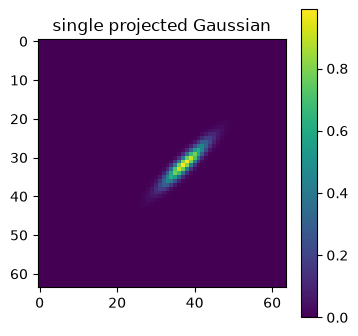

mean_2d: tensor([38., 32.]) 
Sigma_2D:
 tensor([[ 13.5496, -11.9935],
        [-11.9935,  12.7540]])


In [23]:
# a single tilted, elongated Gaussian sitting 5 units in front of the camera
mean_world = torch.tensor([0.3, 0.0, 0.0])
scale = torch.tensor([0.05, 0.25, 0.05])          # long along y -> should look like a streak
quat = torch.tensor([0.92, 0., 0., 0.39])          # rotated somewhat about z

R_cw = torch.eye(3)
t_cw = torch.tensor([0., 0., 5.])
fx = fy = 100.
cx = cy = 32.
H = W = 64

Sigma_world = build_covariance(scale, quat)
mean_cam = world_to_cam_point(mean_world, R_cw, t_cw)
Sigma_cam = world_to_cam_covariance(Sigma_world, R_cw)
mean_2d = project_point(mean_cam, fx, fy, cx, cy)
Sigma_2D = project_covariance_to_2d(Sigma_cam, mean_cam, fx, fy)
Sigma_2D_inv = torch.linalg.inv(Sigma_2D)

ys, xs = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
img = torch.zeros(H, W)
for i in range(H):
    for j in range(W):
        pixel = torch.tensor([xs[i, j].float() + 0.5, ys[i, j].float() + 0.5])
        img[i, j] = eval_gaussian_2d(pixel, mean_2d, Sigma_2D_inv)

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="viridis")
plt.title("single projected Gaussian")
plt.colorbar()
plt.show()
print("mean_2d:", mean_2d, "\nSigma_2D:\n", Sigma_2D)


**Problem to reason about:** the `scale` above is `[0.05, 0.25, 0.05]` — long in
$y$. With `quat` close to identity (rotated only slightly about $z$), the blob should
render as an elongated streak oriented close to vertical, with a slight tilt from the
rotation. If instead you see a *round* blob, that's a signal something upstream (probably
the quaternion or the rotation formula) isn't doing what you think — a good exercise is to
set `quat = torch.tensor([1., 0., 0., 0.])` (no rotation at all) and re-run: you should
get a perfectly vertical streak with zero tilt. Try it.


## Step 9 — Scale up: many Gaussians, vectorized

**Math recap:** Steps 1–7 were all scalar (one Gaussian, sometimes one pixel). Real 3DGS
batches everything:

- Step 1 → `get_covariance()`: shape `(N, 3, 3)` instead of `(3, 3)`
- Steps 2–5 → `project_gaussians()`: `(N, 2)` means, `(N, 2, 2)` covariances
- Steps 6–7 → `render()`: evaluate *all* pixels × *all* Gaussians at once

The only new trick is the **batched quadratic form** for Step 6:

$$\text{quad}[p, n] = (p - \mu_n)^T \Sigma_n^{-1} (p - \mu_n)
\quad\Rightarrow\quad
\texttt{einsum('pni,nij,pnj->pn', diff, Sigma2D\_inv, diff)}$$

And front-to-back compositing (Step 7) becomes a `cumprod` along the splat dimension.

**Your task:** implement the three functions below in order — `get_covariance`,
`project_gaussians`, and `render`. Helper classes (`Camera`, `make_orbit_camera`,
`GaussianModel.__init__`) are provided so you can focus on the batched math.

**Sanity check to reason through first:** with `N=1` and the same numbers as Step 8,
`project_gaussians` should return `mean_2d ≈ (38, 32)` and a tilted `Sigma_2D`.
That's what self-check 9b tests.


In [30]:
# --- scaffolding: camera + parameter container (not your task) ---
class Camera:
    def __init__(self, R_wc, t_wc, fx, fy, cx, cy, H, W):
        self.R = R_wc.to(device)
        self.t = t_wc.to(device)
        self.fx, self.fy, self.cx, self.cy = fx, fy, cx, cy
        self.H, self.W = H, W

    def world_to_cam(self, means):
        return means @ self.R.T + self.t


def make_orbit_camera(angle_rad, radius, H=64, W=64, fov_deg=50.0):
    angle = torch.tensor(angle_rad)
    cam_pos = torch.stack([
        radius * torch.cos(angle),
        torch.tensor(0.3),
        radius * torch.sin(angle),
    ])
    forward = -cam_pos / cam_pos.norm()
    world_up = torch.tensor([0., 1., 0.])
    right = torch.linalg.cross(world_up, forward)
    right = right / right.norm()
    true_up = torch.linalg.cross(forward, right)
    R_cw = torch.stack([right, true_up, forward], dim=0)
    t_cw = -R_cw @ cam_pos
    f = 0.5 * W / torch.tan(torch.tensor(fov_deg * 3.14159265 / 180.0 / 2))
    return Camera(R_cw, t_cw, fx=f, fy=f, cx=W / 2, cy=H / 2, H=H, W=W)


class GaussianModel(nn.Module):
    def __init__(self, n_gaussians, init_means=None):
        super().__init__()
        N = n_gaussians
        means = init_means if init_means is not None else (torch.rand(N, 3) * 2 - 1)
        self.means = nn.Parameter(means.clone())
        self.log_scale = nn.Parameter(torch.log(torch.ones(N, 3) * 0.1))
        q0 = torch.zeros(N, 4)
        q0[:, 0] = 1.0
        self.quat = nn.Parameter(q0 + torch.randn(N, 4) * 0.01) # (N, 4)
        self.opacity_raw = nn.Parameter(torch.randn(N) * 0.1 - 1.0)
        self.color_raw = nn.Parameter(torch.randn(N, 3) * 0.5)

    def _get_normalized_quaternions(self):
        inv_length = 1.0 / (torch.norm(self.quat, dim=-1, keepdim=True) + 1e-8) # (N,1)
        return self.quat * inv_length
    
    def _quat_to_R(self, quat):
        N = quat.shape[0]
        w, x, y, z = quat.unbind(-1)
        R = torch.stack([
            1 - 2 * (y**2 + z**2), 2 * (x*y - w*z),       2 * (x*z + w*y),
            2 * (x*y + w*z),       1 - 2 * (x**2 + z**2), 2 * (y*z - w*x),
            2 * (x*z - w*y),       2 * (y*z + w*x),       1 - 2 * (x**2 + y**2),
        ], dim=-1).reshape(-1, 3, 3)
        return R
    
    def get_covariance(self):
        """Step 1, batched: return (N, 3, 3) covariance matrices."""
        # YOUR CODE HERE
        quat = self._get_normalized_quaternions()
        R = self._quat_to_R(quat) # (N, 3, 3)
        S = torch.diag_embed(torch.exp(self.log_scale)) # (N, 3, 3)
        
        return R @ S @ S @ R.mT # (N, 3, 3)
        
        
    def get_opacity(self):
        return torch.sigmoid(self.opacity_raw) # (N, )

    def get_color(self):
        return torch.sigmoid(self.color_raw) # (N, 3)


In [31]:
# --- self-check 9a: batched covariance ---
try:
    m = GaussianModel(3).to(device)
    with torch.no_grad():
        m.log_scale[:] = torch.log(torch.tensor([[0.1, 0.2, 0.3],
                                                  [0.2, 0.2, 0.2],
                                                  [0.05, 0.25, 0.05]], device=device))
        m.quat[:] = torch.tensor([[1., 0., 0., 0.],
                                   [1., 0., 0., 0.],
                                   [0.92, 0., 0., 0.39]], device=device)
    Sigma = m.get_covariance()
    assert Sigma.shape == (3, 3, 3), Sigma.shape
    expected0 = build_covariance(m.log_scale[0].exp().cpu(), m.quat[0].cpu())
    assert torch.allclose(Sigma[0].cpu(), expected0, atol=1e-4), f"batch[0]: {Sigma[0]}, expected {expected0}"
    print("Step 9a PASSED: Sigma.shape =", tuple(Sigma.shape))
except NotImplementedError:
    print("Fill in GaussianModel.get_covariance above, then re-run.")


Step 9a PASSED: Sigma.shape = (3, 3, 3)


In [33]:
from statistics import covariance


def project_points(x_cam, cam: Camera):
    x = x_cam[..., 0] # (N)
    y = x_cam[..., 1]
    z = x_cam[..., 2]
    
    u = cam.fx * x / z + cam.cx # (N,)
    v = cam.fy * y / z + cam.cy # (N,)
    
    
    return torch.stack([u, v], dim=-1) # (N, 2)

def perspective_jacobians(x_cam, fx, fy):
    x, y, z = x_cam[..., 0], x_cam[..., 1], x_cam[..., 2] # (N,)
    zero = torch.zeros_like(x)
    J = torch.stack([
        fx / z, zero,     -fx * x / z**2,
        zero,     fy / z, -fy * y / z**2,
    ], dim=-1) # N, 6
    
    return J.reshape(-1, 2, 3)

    
def project_gaussians(model: GaussianModel, cam: Camera):
    """Steps 2-5, batched over N Gaussians.

    Return:
        mean_2d: (N, 2)
        Sigma2D: (N, 2, 2)
        depth:   (N,)  camera-space z (for sorting)
    """
    # YOUR CODE HERE
    means = model.means # (N, 3)
    means_cam = cam.world_to_cam(means) # (N, 3)
    means_2d = project_points(means_cam, cam)
    
    covariance_cam = world_to_cam_covariance(model.get_covariance(), cam.R)
    J = perspective_jacobians(means_cam, cam.fx, cam.fy) # (N, 2, 3)
    Sigma2D = J @ covariance_cam @ J.mT
    
    depth = means_cam[:, 2].clamp(min=1e-3)
    
    Sigma2D = Sigma2D + 0.15 * torch.eye(2, device=Sigma2D.device, dtype=Sigma2D.dtype)
    
    return means_2d, Sigma2D, depth


In [34]:
# --- self-check 9b: batched projection matches Step 8 ---
try:
    m = GaussianModel(1).to(device)
    with torch.no_grad():
        m.means[:] = torch.tensor([[0.3, 0.0, 0.0]], device=device)
        m.log_scale[:] = torch.log(torch.tensor([[0.05, 0.25, 0.05]], device=device))
        m.quat[:] = torch.tensor([[0.92, 0., 0., 0.39]], device=device)
    cam = Camera(torch.eye(3), torch.tensor([0., 0., 5.]), 100., 100., 32., 32., 64, 64)

    mean_2d, Sigma2D, depth = project_gaussians(m, cam)

    assert mean_2d.shape == (1, 2), mean_2d.shape
    assert Sigma2D.shape == (1, 2, 2), Sigma2D.shape
    assert torch.allclose(mean_2d[0], torch.tensor([38., 32.], device=device), atol=1e-3), mean_2d[0]
    assert torch.allclose(depth, torch.tensor([5.0], device=device), atol=1e-3), depth

    # also compare against the scalar helpers from Steps 1-5
    Sigma_world = build_covariance(m.log_scale[0].exp().cpu(), m.quat[0].cpu())
    mean_cam = world_to_cam_point(m.means[0].cpu(), torch.eye(3), torch.tensor([0., 0., 5.]))
    Sigma_cam = world_to_cam_covariance(Sigma_world, torch.eye(3))
    Sigma2D_ref = project_covariance_to_2d(Sigma_cam, mean_cam, 100., 100.)

    assert torch.allclose(Sigma2D[0].cpu(), Sigma2D_ref, atol=1e-2), f"got {Sigma2D[0]}, expected {Sigma2D_ref}"
    print("Step 9b PASSED: mean_2d =", mean_2d[0].tolist(), "depth =", depth.item())
except NotImplementedError:
    print("Fill in project_gaussians above, then re-run.")


Step 9b PASSED: mean_2d = [38.0, 32.0] depth = 5.0


In [59]:

def eval_gaussian_2d(pixel, mean2d, Sigma2D_inv):
    """
    pixel (P, 1, 2)
    mean2d (N, 2)
    Sigma2D_inv(N, 2, 2)
    """
    diff = pixel - mean2d # (P, N, 2)
    quad = (diff.unsqueeze(-2) @ Sigma2D_inv.unsqueeze(0) @ diff.unsqueeze(-1)).squeeze(-1).squeeze(-1)
    return torch.exp(-0.5 * quad) 

def render(model: GaussianModel, cam):
    """Steps 6-7, batched over N Gaussians and all pixels.

    Return an (H, W, 3) image tensor.
    """
    # (N, 2), (N, 2, 2), (N,)
    means_2D, Sigmas_2D, depths = project_gaussians(model, cam)
    
    perm = depths.argsort()
    means_2D = means_2D[perm, ...]
    Sigmas_2D = Sigmas_2D[perm,...]
    Sigmas_2D_inv = torch.linalg.inv(Sigmas_2D)
    opacities = model.get_opacity()[perm] 
    colors = model.get_color()[perm, ...] # (N, 3)
    
    ys, xs = torch.meshgrid(torch.arange(cam.H, device=device), torch.arange(cam.W, device=device), indexing="ij")
    coords = torch.stack([xs.float() + 0.5, ys.float() + 0.5], dim=-1)
    coords = coords.reshape(-1, 2) # (H*W, 2) -> (P, 2)
    
    projections = eval_gaussian_2d(coords.unsqueeze(1), means_2D, Sigmas_2D_inv) # (P, N)
    alphas = projections * opacities # (P, N)
    alphas = torch.clamp(alphas, min=0, max=0.999)
    
    transparency = 1 - alphas # (P, N)
    weights = torch.cumprod(transparency, dim=1) # (P, N)
    weights = torch.roll(weights, 1, dims=1)
    weights[..., 0] = 1.0 # (P, N)
    
    weights *= alphas
    color = torch.sum(colors * weights.unsqueeze(-1), dim=1)  # (P, 3)
    return color.reshape(cam.H, cam.W, 3)


In [61]:
# --- self-check 9c: render produces a non-blank image ---
try:
    m = GaussianModel(1).to(device)
    with torch.no_grad():
        m.means[:] = torch.tensor([[0.3, 0.0, 0.0]], device=device)
        m.log_scale[:] = torch.log(torch.tensor([[0.05, 0.25, 0.05]], device=device))
        m.quat[:] = torch.tensor([[0.92, 0., 0., 0.39]], device=device)
        m.opacity_raw[:] = 5.0   # mostly opaque
        m.color_raw[:] = torch.tensor([5.0, -5.0, -5.0])  # red-ish after sigmoid
    cam = Camera(torch.eye(3), torch.tensor([0., 0., 5.]), 100., 100., 32., 32., 64, 64)

    img = render(m, cam)
    assert img.shape == (64, 64, 3), img.shape
    assert img.max() > 0.1, "image looks blank — check alpha / gaussian eval"
    peak = img.max(dim=0).values.max(dim=0).values
    assert peak.argmax() >= 0, peak
    print("Step 9c PASSED: img.shape =", tuple(img.shape), "max =", round(img.max().item(), 3))
except NotImplementedError:
    print("Fill in render above, then re-run.")


Step 9c PASSED: img.shape = (64, 64, 3) max = 0.977


**Solution** (try all three functions yourself first — scroll past once you've attempted them):

In [ ]:
class GaussianModel(nn.Module):
    def __init__(self, n_gaussians, init_means=None):
        super().__init__()
        N = n_gaussians
        means = init_means if init_means is not None else (torch.rand(N, 3) * 2 - 1)
        self.means = nn.Parameter(means.clone())
        self.log_scale = nn.Parameter(torch.log(torch.ones(N, 3) * 0.1))
        q0 = torch.zeros(N, 4)
        q0[:, 0] = 1.0
        self.quat = nn.Parameter(q0 + torch.randn(N, 4) * 0.01)
        self.opacity_raw = nn.Parameter(torch.randn(N) * 0.1 - 1.0)
        self.color_raw = nn.Parameter(torch.randn(N, 3) * 0.5)

    def get_covariance(self):
        q = F.normalize(self.quat, dim=-1)
        w, x, y, z = q.unbind(-1)
        N = q.shape[0]
        R = torch.stack([
            1 - 2 * (y**2 + z**2), 2 * (x*y - w*z),       2 * (x*z + w*y),
            2 * (x*y + w*z),       1 - 2 * (x**2 + z**2), 2 * (y*z - w*x),
            2 * (x*z - w*y),       2 * (y*z + w*x),       1 - 2 * (x**2 + y**2),
        ], dim=-1).reshape(N, 3, 3)
        S = torch.diag_embed(torch.exp(self.log_scale))
        RS = R @ S
        return RS @ RS.transpose(-1, -2)

    def get_opacity(self):
        return torch.sigmoid(self.opacity_raw)

    def get_color(self):
        return torch.sigmoid(self.color_raw)


def project_gaussians(model, cam):
    means_cam = cam.world_to_cam(model.means)
    z = means_cam[:, 2].clamp(min=1e-3)
    mean_2d = torch.stack([
        cam.fx * means_cam[:, 0] / z + cam.cx,
        cam.fy * means_cam[:, 1] / z + cam.cy,
    ], dim=-1)

    Sigma3D = model.get_covariance()
    R = cam.R.unsqueeze(0).expand(Sigma3D.shape[0], -1, -1)
    Sigma_cam = R @ Sigma3D @ R.transpose(-1, -2)

    N = means_cam.shape[0]
    J = torch.zeros(N, 2, 3, device=means_cam.device)
    x, y = means_cam[:, 0], means_cam[:, 1]
    J[:, 0, 0] = cam.fx / z
    J[:, 0, 2] = -cam.fx * x / (z * z)
    J[:, 1, 1] = cam.fy / z
    J[:, 1, 2] = -cam.fy * y / (z * z)

    Sigma2D = J @ Sigma_cam @ J.transpose(-1, -2)
    Sigma2D = Sigma2D + 0.15 * torch.eye(2, device=means_cam.device)
    return mean_2d, Sigma2D, z


def render(model, cam):
    mean_2d, Sigma2D, depth = project_gaussians(model, cam)
    opacity = model.get_opacity()
    color = model.get_color()

    order = torch.argsort(depth)
    mean_2d = mean_2d[order]
    Sigma2D = Sigma2D[order]
    opacity = opacity[order]
    color = color[order]

    ys, xs = torch.meshgrid(
        torch.arange(cam.H, device=mean_2d.device),
        torch.arange(cam.W, device=mean_2d.device),
        indexing="ij",
    )
    pix = torch.stack([xs.float() + 0.5, ys.float() + 0.5], dim=-1).reshape(-1, 2)

    Sigma2D_inv = torch.linalg.inv(Sigma2D)
    diff = pix.unsqueeze(1) - mean_2d.unsqueeze(0)          # (P, N, 2)
    quad = torch.einsum("pni,nij,pnj->pn", diff, Sigma2D_inv, diff)
    gauss = torch.exp(-0.5 * quad)
    alpha = (opacity.unsqueeze(0) * gauss).clamp(0, 0.999)

    T = torch.cumprod(torch.cat([torch.ones_like(alpha[:, :1]), 1 - alpha[:, :-1]], dim=1), dim=1)
    weight = alpha * T
    image = (weight.unsqueeze(-1) * color.unsqueeze(0)).sum(dim=1)
    return image.reshape(cam.H, cam.W, 3)

print("Step 9 solution loaded")


**Checkpoint problem:** before training anything, render one random-init
`GaussianModel` from one camera and just `plt.imshow` it. It should look like faint
colored noise blobs — not black, not an error. If you get an error here, print
`mean_2d.shape`, `Sigma2D.shape` and compare against what Steps 1-5 produced for a
single Gaussian.


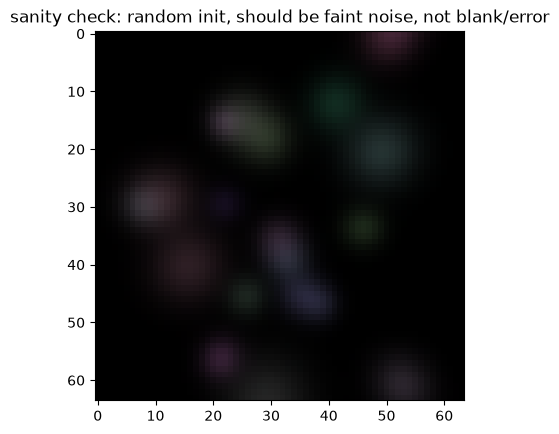

In [60]:
torch.manual_seed(1)
debug_model = GaussianModel(n_gaussians=20).to(device)
debug_cam = make_orbit_camera(0.0, radius=2.5)
with torch.no_grad():
    debug_img = render(debug_model, debug_cam).clamp(0, 1).cpu()
plt.imshow(debug_img)
plt.title("sanity check: random init, should be faint noise, not blank/error")
plt.show()


## Step 10 — Train on a synthetic scene

**Math recap:** same loss as NeRF-style reconstruction — MSE between rendered and target
images — but now `.backward()` flows through your entire batched renderer into every
learnable parameter: `means`, `log_scale`, `quat`, `opacity_raw`, `color_raw`.

**Your task:** implement `make_ground_truth_scene` (builds a fixed target scene) and
`train_one_step` (one optimizer step on one random camera view).

**Problem to reason through first:** we deliberately initialize the trainable model with
*more* Gaussians (`120`) than the ground truth (`60`). The optimizer should still be
able to fit the two colored blobs — extra Gaussians can fade to near-zero opacity.
After ~500 steps the loss should drop well below `0.01`.


In [67]:
import numpy as np

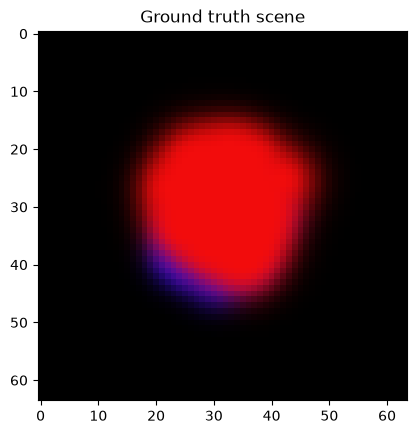

In [70]:
def make_ground_truth_scene(n=60):
    gt = GaussianModel(n)
    with torch.no_grad():
        half = n // 2
        gt.means[:half] = torch.randn(half, 3) * 0.15 + torch.tensor([0.4, 0.0, 0.0])
        gt.means[half:] = torch.randn(n - half, 3) * 0.15 + torch.tensor([-0.4, 0.1, 0.0])
        gt.color_raw[:half] = 3.0 * torch.tensor([1., -1., -1.])
        gt.color_raw[half:] = 3.0 * torch.tensor([-1., -1., 1.])
        gt.opacity_raw[:] = 4.0
        gt.log_scale[:] = torch.log(torch.tensor(0.12))
    return gt.to(device)

with torch.no_grad():
    debug_img = render(make_ground_truth_scene(), debug_cam).clamp(0, 1).cpu()
plt.imshow(debug_img)
plt.title("Ground truth scene")
plt.show()

def train_one_step(model, gt_model, cams, targets, optim, step):
    """Render one view, compute MSE loss, backprop, optimizer step. Return scalar loss."""
    # YOUR CODE HERE
    idx = step % len(cams)
    cam = cams[idx]
    target = targets[idx] # (H, W, 3)
    
    prediction = render(model, cam)
    
    loss = torch.nn.functional.mse_loss(prediction, target)
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    return loss.detach()


In [71]:
# --- self-check 10: ground-truth scene renders, training loss decreases ---
try:
    gt = make_ground_truth_scene(60).to(device)
    assert gt.means.shape == (60, 3), gt.means.shape

    cams = [make_orbit_camera(float(a), radius=2.5)
            for a in torch.linspace(0, 2 * 3.14159, 6)[:-1]]
    with torch.no_grad():
        targets = [render(gt, c) for c in cams]
    assert all(t.shape == (64, 64, 3) for t in targets)

    model = GaussianModel(n_gaussians=120).to(device)
    optim = torch.optim.Adam([
        {"params": [model.means], "lr": 0.01},
        {"params": [model.log_scale], "lr": 0.01},
        {"params": [model.quat], "lr": 0.01},
        {"params": [model.opacity_raw], "lr": 0.05},
        {"params": [model.color_raw], "lr": 0.02},
    ])

    loss0 = train_one_step(model, gt, cams, targets, optim, step=0).item()
    for s in range(1, 101):
        train_one_step(model, gt, cams, targets, optim, step=s)
    loss100 = train_one_step(model, gt, cams, targets, optim, step=101).item()
    assert loss100 < loss0, f"loss did not decrease: {loss0:.4f} -> {loss100:.4f}"
    print(f"Step 10 PASSED: loss {loss0:.4f} -> {loss100:.4f}")
except NotImplementedError:
    print("Fill in make_ground_truth_scene and train_one_step above, then re-run.")


Step 10 PASSED: loss 0.0540 -> 0.0048


**Solution:**

In [72]:
def make_ground_truth_scene(n=60):
    gt = GaussianModel(n)
    with torch.no_grad():
        half = n // 2
        gt.means[:half] = torch.randn(half, 3) * 0.15 + torch.tensor([0.4, 0.0, 0.0])
        gt.means[half:] = torch.randn(n - half, 3) * 0.15 + torch.tensor([-0.4, 0.1, 0.0])
        gt.color_raw[:half] = 3.0 * torch.tensor([1., -1., -1.])
        gt.color_raw[half:] = 3.0 * torch.tensor([-1., -1., 1.])
        gt.opacity_raw[:] = 4.0
        gt.log_scale[:] = torch.log(torch.tensor(0.12))
    return gt.to(device)


def train_one_step(model, gt_model, cams, targets, optim, step):
    cam_idx = step % len(cams)
    pred = render(model, cams[cam_idx])
    loss = F.mse_loss(pred, targets[cam_idx])
    optim.zero_grad()
    loss.backward()
    optim.step()
    return loss


gt_model = make_ground_truth_scene()
cams = [make_orbit_camera(float(a), radius=2.5)
        for a in torch.linspace(0, 2 * 3.14159, 6)[:-1]]
with torch.no_grad():
    targets = [render(gt_model, c) for c in cams]

model = GaussianModel(n_gaussians=120).to(device)
optim = torch.optim.Adam([
    {"params": [model.means], "lr": 0.01},
    {"params": [model.log_scale], "lr": 0.01},
    {"params": [model.quat], "lr": 0.01},
    {"params": [model.opacity_raw], "lr": 0.05},
    {"params": [model.color_raw], "lr": 0.02},
])

losses = []
for step in range(600):
    loss = train_one_step(model, gt_model, cams, targets, optim, step)
    losses.append(loss.item())
    if step % 100 == 0:
        print(f"step {step:4d}  loss {loss.item():.5f}")


step    0  loss 0.04924
step  100  loss 0.00282
step  200  loss 0.00080
step  300  loss 0.00034
step  400  loss 0.00019
step  500  loss 0.00014


**Problem to try:** if `losses` isn't decreasing, the most common causes, roughly
in order of likelihood:
1. Learning rates too high for `means` (positions overshoot) — try dropping to `0.003`.
2. Too few Gaussians relative to scene complexity — bump `n_gaussians` up.
3. `opacity_raw` initialized too negative (everything starts near-invisible so gradients
   are tiny) — check `model.get_opacity().mean()` right after init; if it's near 0, nudge
   the init in `GaussianModel.__init__` less negative.

Try deliberately breaking something (e.g. set the `means` lr to `1.0`) and watch the loss
curve explode — it's a fast way to build intuition for what failure modes look like.


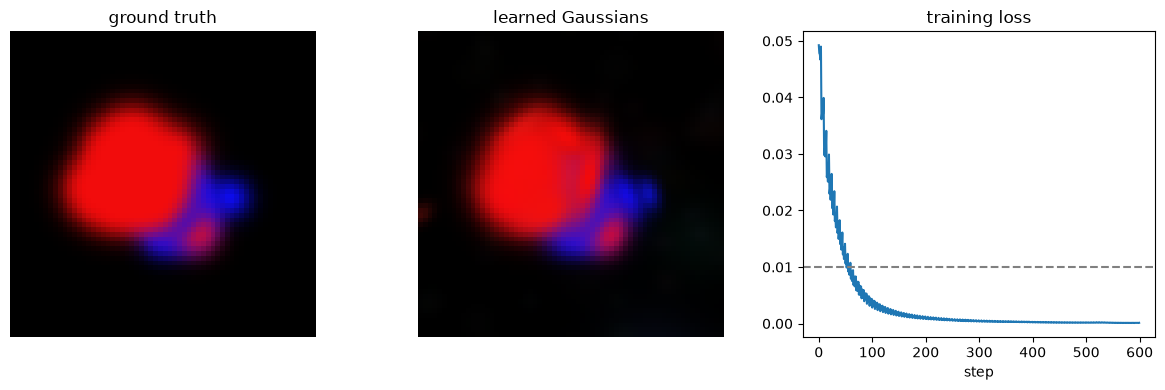

In [73]:
with torch.no_grad():
    test_cam = make_orbit_camera(0.5, radius=2.5)
    gt_img = render(gt_model, test_cam).clamp(0, 1).cpu()
    pred_img = render(model, test_cam).clamp(0, 1).cpu()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_img); axs[0].set_title("ground truth"); axs[0].axis("off")
axs[1].imshow(pred_img); axs[1].set_title("learned Gaussians"); axs[1].axis("off")
axs[2].plot(losses); axs[2].set_title("training loss"); axs[2].axhline(0.01, ls="--", c="gray")
axs[2].set_xlabel("step")
plt.tight_layout()
plt.show()


## Where to go next

- Swap `color_raw` for spherical-harmonic coefficients so color depends on viewing angle.
- Add adaptive density control: every ~100 steps, split Gaussians with large positional
  gradients and prune ones with `get_opacity()` below a threshold.
- Replace the synthetic scene with real posed images (this is where your NeRF-pipeline
  experience with COLMAP directly transfers — same calibration step, same idea of
  "get poses first, optimize the representation second").
